In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

In [6]:
ticker = 'AAPL'
data = yf.download(ticker, start="2023-01-01", end="2024-01-01")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-01-03,123.096016,128.833995,122.210219,128.223785,112117500
2023-01-04,124.365669,126.629372,123.105873,124.887303,89113600
2023-01-05,123.046806,125.753403,122.790915,125.123505,80962700
2023-01-06,127.574196,128.233619,122.918854,124.021180,87754700
2023-01-09,128.095886,131.304445,127.839995,128.410843,70790800


In [21]:
data["Returns"] = data["Close"].pct_change()
data = data.dropna()
data.head()


Price,Close,High,Low,Open,Volume,Returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2023-01-04,124.365669,126.629372,123.105873,124.887303,89113600,0.010314
2023-01-05,123.046806,125.753403,122.790915,125.123505,80962700,-0.010605
2023-01-06,127.574196,128.233619,122.918854,124.021180,87754700,0.036794
2023-01-09,128.095886,131.304445,127.839995,128.410843,70790800,0.004089
2023-01-10,128.666687,129.188321,126.097880,128.204104,63896200,0.004456


In [8]:
volatility = data["Returns"].std() * np.sqrt(252)
volatility

np.float64(0.19954324857530228)

In [47]:
S = data["Close"].iloc[-1].values[0]
K = 200
T = 1
r = 0.05
sigma = volatility
print("S = ",S)

S =  190.5504608154297


In [48]:
d1 = (np.log(S/K) + (r + sigma**2/2)*T)/(sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
call_price = S * norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


In [49]:
print("Current Stock Price:", float(S))
print("Estimated Volatility:", sigma)
print("Call Option Price:", float(call_price))

Current Stock Price: 190.5504608154297
Estimated Volatility: 0.19954324857530228
Call Option Price: 15.284546249454749


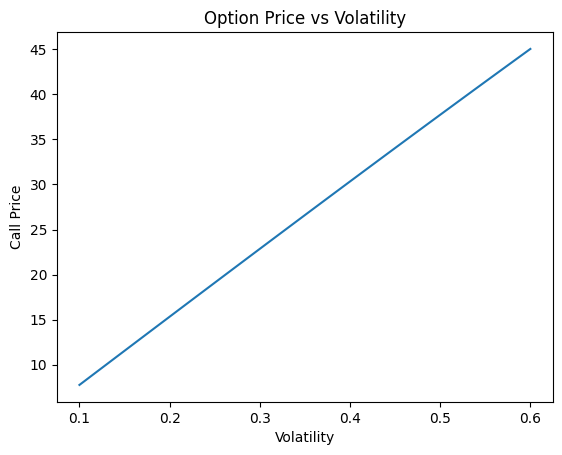

In [50]:
vol_range = np.linspace(0.1,0.6,50)
prices = []
for vol in vol_range:
    d1 = (np.log(S/K) + (r + 0.5 * vol**2) * T) / (vol * np.sqrt(T))
    d2 = d1 - vol * np.sqrt(T)
    price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    prices.append(price)

plt.plot(vol_range,prices)
plt.xlabel("Volatility")
plt.ylabel("Call Price")
plt.title("Option Price vs Volatility")
plt.show()

In [57]:
simulations = 1000000
Z = np.random.normal(0,1,simulations)

ST = S* np.exp((r-sigma**2/2)*T + sigma*np.sqrt(T)*Z)

payoff = np.maximum(ST-K,0)

mc_price = np.exp(-r*T) * np.mean(payoff)

print("Monte Carlo Price:",mc_price)

Monte Carlo Price: 15.30051054976621


In [58]:
##Comparison
print("Black-Scholes Price:", call_price)
print("Monte Carlo Price:", mc_price)

Black-Scholes Price: 15.284546249454749
Monte Carlo Price: 15.30051054976621


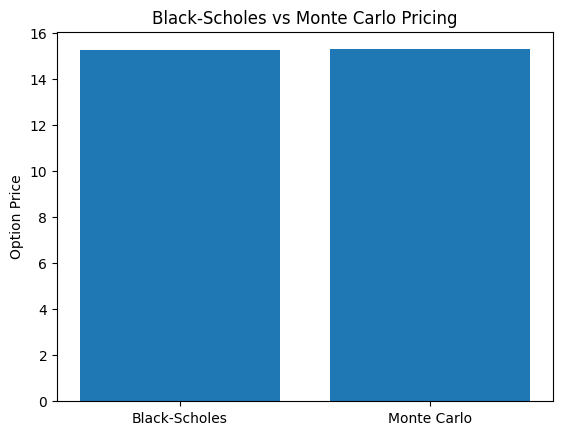

In [59]:
methods = ["Black-Scholes","Monte Carlo"]
prices = [call_price, mc_price]

plt.bar(methods, prices)
plt.ylabel("Option Price")
plt.title("Black-Scholes vs Monte Carlo Pricing")
plt.show()

In [60]:
error = abs(call_price - mc_price)

print("Black-Scholes Price:", call_price)
print("Monte Carlo Price:", mc_price)
print("Pricing Error:", error)

Black-Scholes Price: 15.284546249454749
Monte Carlo Price: 15.30051054976621
Pricing Error: 0.015964300311461344


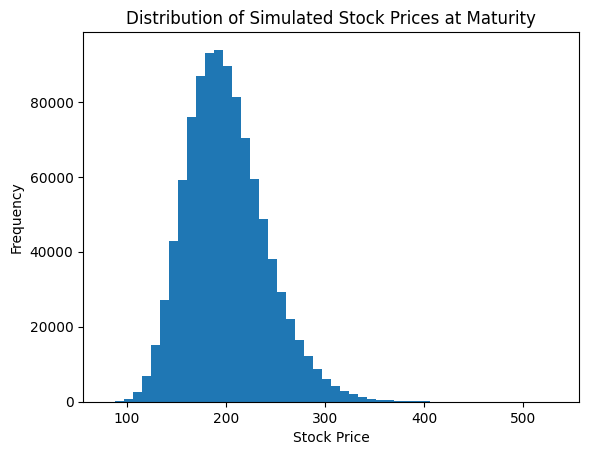

In [61]:
plt.hist(ST, bins=50)
plt.title("Distribution of Simulated Stock Prices at Maturity")
plt.xlabel("Stock Price")
plt.ylabel("Frequency")
plt.show()

In [64]:
delta = norm.cdf(d1)
gamma = norm.pdf(d1) / (S*sigma*np.sqrt(T))
vega = S*norm.pdf(d1)*np.sqrt(T)
     
print("Option Greeks")

print("Delta:", delta)
print("Gamma:", gamma)
print("Vega:", vega)     

Option Greeks
Delta: 0.6189278446466995
Gamma: 0.010022379953260637
Vega: 72.61526190175283
